# 06 — GAN-Based Ocular Image Augmentation

## Project
**Identity-Preserving Synthetic Ocular Image Generation Using Conditional Diffusion Models**

## Dataset
**CASIA-Iris-Thousand**

## Objective

This notebook investigates Generative Adversarial Networks (GANs) as a
synthetic image generation approach for ocular biometric augmentation.

The generated ocular images will later be used to augment the training
dataset and evaluate their effect on ocular recognition performance.

## Experimental Motivation

GANs are a traditional generative modeling approach that can generate
realistic images by learning the distribution of the training data.

However, for biometric applications, generating visually realistic images
alone is not sufficient. The generated image should also retain useful
identity-related characteristics.

Therefore, this experiment will consider:

1. Image realism
2. Image diversity
3. Identity preservation
4. Recognition performance after augmentation

## Experimental Data Rule

Only the training portion of CASIA-Iris-Thousand will be used for GAN
training and synthetic image generation.

- Training set: 12,000 images
- Validation set: 4,000 images — unchanged
- Test set: 4,000 images — unchanged
- Eye identities: 2,000

The validation and test sets will not be used to train the GAN.

## Experimental Pipeline

Original Training Images
        ↓
GAN Training
        ↓
Synthetic Ocular Images
        ↓
Quality / Identity Evaluation
        ↓
Training Dataset Augmentation
        ↓
ResNet18 Recognition
        ↓
Test Performance

## Comparison

The GAN experiment will later be compared with:

- Baseline — Original images
- Traditional Augmentation
- GAN Augmentation
- Diffusion Augmentation

The same recognition architecture and test set will be maintained for
comparison across experiments.

In [3]:
# Cell 2 — Libraries and Project Configuration

import os
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Libraries imported successfully.
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [4]:
# Cell 3 — Mount Google Drive and Configure Project Paths

from google.colab import drive

drive.mount("/content/drive")

project_path = Path(
    "/content/drive/MyDrive/Ocular_Project"
)

dataset_path = (
    project_path
    / "datasets"
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
)

split_csv_path = (
    project_path
    / "results"
    / "CASIA_Thousand_data_split.csv"
)

print("Project path:", project_path)
print("Dataset path:", dataset_path)
print("Split CSV:", split_csv_path)

Mounted at /content/drive
Project path: /content/drive/MyDrive/Ocular_Project
Dataset path: /content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand
Split CSV: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_data_split.csv


In [5]:
# Cell 4 — Load and Verify Dataset Split

split_df = pd.read_csv(split_csv_path)

# Remove accidental index column if present
if "Unnamed: 0" in split_df.columns:
    split_df = split_df.drop(columns=["Unnamed: 0"])

# Create splits
train_df = split_df[
    split_df["split"] == "train"
].reset_index(drop=True)

val_df = split_df[
    split_df["split"] == "validation"
].reset_index(drop=True)

test_df = split_df[
    split_df["split"] == "test"
].reset_index(drop=True)

# Basic verification
print("Dataset split loaded successfully.")
print()
print("Total images:", len(split_df))
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))
print()
print("Number of eye identities:",
      split_df["identity"].nunique())

Dataset split loaded successfully.

Total images: 20000
Training images: 12000
Validation images: 4000
Test images: 4000

Number of eye identities: 2000


In [6]:
# Cell 5 — Check Local Dataset

local_image_root = (
    Path("/content/CASIA-Iris-Thousand")
    / "CASIA-Iris-Thousand"
)

print("Local image root:")
print(local_image_root)

print()
print("Root exists:", local_image_root.exists())

# Check a sample image
sample_image = (
    local_image_root
    / "000"
    / "L"
    / "S5000L00.jpg"
)

print("Sample image exists:", sample_image.exists())

if sample_image.exists():
    image = Image.open(sample_image)
    print("Sample image size:", image.size)
    print("Sample image mode:", image.mode)

Local image root:
/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand

Root exists: False
Sample image exists: False


In [7]:
# Cell 6 — Copy Dataset ZIP to Local Colab Storage

import shutil

zip_path = project_path / "datasets" / "archive.zip"
local_zip_path = Path("/content/CASIA-Iris-Thousand.zip")

print("Copying dataset ZIP to local Colab storage...")

shutil.copy2(zip_path, local_zip_path)

print("Dataset ZIP copied successfully.")
print(
    f"Local ZIP size: "
    f"{local_zip_path.stat().st_size / (1024**2):.2f} MB"
)

Copying dataset ZIP to local Colab storage...
Dataset ZIP copied successfully.
Local ZIP size: 490.79 MB


In [8]:
# Cell 7 — Extract Dataset to Local Storage

import zipfile

extract_base = Path("/content")

print("Extracting dataset...")

with zipfile.ZipFile(local_zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_base)

print("Dataset extracted successfully.")

Extracting dataset...
Dataset extracted successfully.


In [9]:
# Cell 8 — Verify Extracted Dataset Structure

print("Searching for subject folder '000'...")

subject_matches = list(
    Path("/content").rglob("000")
)

print("Number of matches:", len(subject_matches))

for match in subject_matches[:10]:
    print(" -", match)

print()

# Expected dataset root
local_image_root = (
    Path("/content/CASIA-Iris-Thousand")
    / "CASIA-Iris-Thousand"
)

print("Local image root:")
print(local_image_root)

print()
print("Root exists:", local_image_root.exists())

# Verify one actual image
sample_image = (
    local_image_root
    / "000"
    / "L"
    / "S5000L00.jpg"
)

print("Sample image exists:", sample_image.exists())

if sample_image.exists():
    image = Image.open(sample_image)
    print("Sample image size:", image.size)
    print("Sample image mode:", image.mode)

Searching for subject folder '000'...
Number of matches: 3
 - /content/drive/.Encrypted/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000
 - /content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000
 - /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000

Local image root:
/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand

Root exists: True
Sample image exists: True
Sample image size: (640, 480)
Sample image mode: L


In [10]:
# Cell 9 — Create Identity Mapping for Conditional GAN

# Add local image paths to the training dataframe
local_root = Path("/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand")

def convert_to_local_path(original_path):
    original_path = Path(original_path)

    # Extract subject, eye, and filename
    subject = original_path.parent.parent.name
    eye = original_path.parent.name
    filename = original_path.name

    return str(local_root / subject / eye / filename)

train_gan_df = train_df.copy()
train_gan_df["local_path"] = train_gan_df["image_path"].apply(convert_to_local_path)

# Verify paths
print("Total GAN training images:", len(train_gan_df))
print("Existing local images:", train_gan_df["local_path"].apply(os.path.exists).sum())
print("Unique eye identities:", train_gan_df["identity"].nunique())

# Create identity → integer label mapping
gan_identity_to_label = {
    identity: label
    for label, identity in enumerate(
        sorted(train_gan_df["identity"].unique())
    )
}

gan_label_to_identity = {
    label: identity
    for identity, label in gan_identity_to_label.items()
}

print()
print("Number of GAN classes:", len(gan_identity_to_label))
print("Example mappings:")
for identity, label in list(gan_identity_to_label.items())[:5]:
    print(f"  {identity} → {label}")

Total GAN training images: 12000
Existing local images: 12000
Unique eye identities: 2000

Number of GAN classes: 2000
Example mappings:
  000_L → 0
  000_R → 1
  001_L → 2
  001_R → 3
  002_L → 4


In [11]:
# Cell 10 — GAN Image Transform

GAN_IMAGE_SIZE = 128

gan_transform = transforms.Compose([
    transforms.CenterCrop(480),
    transforms.Resize((GAN_IMAGE_SIZE, GAN_IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

print("GAN image size:", GAN_IMAGE_SIZE)
print("Expected tensor shape: [1, 128, 128]")
print("Expected value range: [-1, 1]")

GAN image size: 128
Expected tensor shape: [1, 128, 128]
Expected value range: [-1, 1]


In [12]:
# Cell 11 — GAN Dataset Class

class GANDataset(Dataset):
    def __init__(self, dataframe, transform=None, identity_to_label=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.identity_to_label = identity_to_label

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = row["local_path"]
        identity = row["identity"]

        # Load grayscale ocular image
        image = Image.open(image_path).convert("L")

        # Apply GAN preprocessing
        if self.transform:
            image = self.transform(image)

        # Convert identity to integer label
        label = self.identity_to_label[identity]

        return image, label


print("GANDataset class created successfully.")

GANDataset class created successfully.


In [13]:
# Cell 12 — Create GAN Dataset

gan_dataset = GANDataset(
    dataframe=train_gan_df,
    transform=gan_transform,
    identity_to_label=gan_identity_to_label
)

print("GAN dataset created successfully.")
print("Number of samples:", len(gan_dataset))

# Check one sample
sample_image, sample_label = gan_dataset[0]

print("Sample tensor shape:", sample_image.shape)
print("Sample tensor dtype:", sample_image.dtype)
print("Sample tensor min:", sample_image.min().item())
print("Sample tensor max:", sample_image.max().item())
print("Sample label:", sample_label)
print("Sample identity:", gan_label_to_identity[sample_label])

GAN dataset created successfully.
Number of samples: 12000
Sample tensor shape: torch.Size([1, 128, 128])
Sample tensor dtype: torch.float32
Sample tensor min: -0.9921568632125854
Sample tensor max: 0.7803921699523926
Sample label: 0
Sample identity: 000_L


In [14]:
# Cell 13 — GAN DataLoader

GAN_BATCH_SIZE = 64

gan_loader = DataLoader(
    gan_dataset,
    batch_size=GAN_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("GAN DataLoader created successfully.")
print("Batch size:", GAN_BATCH_SIZE)
print("Number of batches:", len(gan_loader))

# Verify one batch
images, labels = next(iter(gan_loader))

print()
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
print("Image range:", images.min().item(), "to", images.max().item())

GAN DataLoader created successfully.
Batch size: 64
Number of batches: 188

Batch image shape: torch.Size([64, 1, 128, 128])
Batch label shape: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64
Image range: -1.0 to 0.8509804010391235


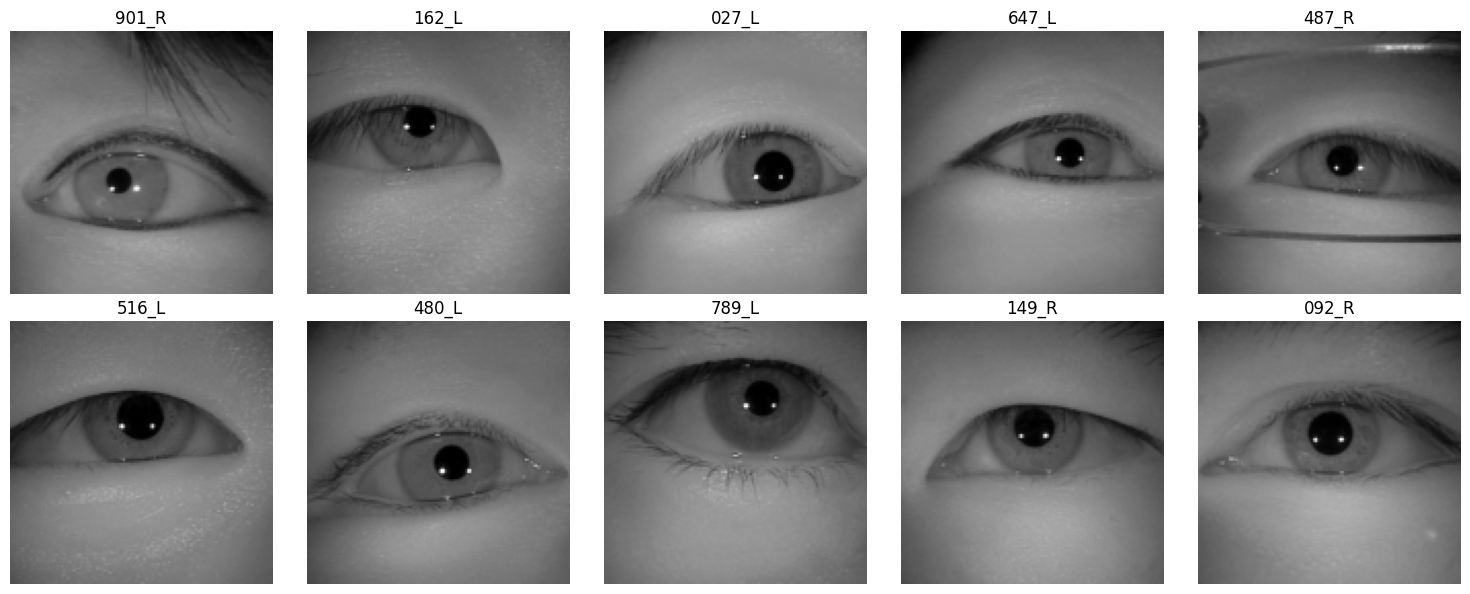

In [15]:
# Cell 14 — Visualize GAN Input Images

images, labels = next(iter(gan_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    # Convert from [-1, 1] back to [0, 1] for display
    image = images[i].squeeze(0)
    image = (image + 1) / 2

    ax.imshow(image, cmap="gray")
    ax.set_title(gan_label_to_identity[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Cell 15 — GAN Configuration

LATENT_DIM = 100
NUM_CLASSES = 2000
EMBEDDING_DIM = 64
IMAGE_SIZE = 128
CHANNELS = 1

print("GAN Configuration")
print("------------------")
print("Latent dimension:", LATENT_DIM)
print("Number of classes:", NUM_CLASSES)
print("Identity embedding dimension:", EMBEDDING_DIM)
print("Image size:", IMAGE_SIZE)
print("Channels:", CHANNELS)

GAN Configuration
------------------
Latent dimension: 100
Number of classes: 2000
Identity embedding dimension: 64
Image size: 128
Channels: 1


In [17]:
# Cell 16 — Conditional GAN Generator

class Generator(nn.Module):
    def __init__(
        self,
        latent_dim=LATENT_DIM,
        num_classes=NUM_CLASSES,
        embedding_dim=EMBEDDING_DIM
    ):
        super().__init__()

        # Convert identity label into a learnable embedding
        self.identity_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )

        # Noise + identity information
        input_dim = latent_dim + embedding_dim

        # Project into a small spatial feature map
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512 * 8 * 8),
            nn.BatchNorm1d(512 * 8 * 8),
            nn.ReLU(True)
        )

        # Upsampling:
        # 8x8 → 16x16 → 32x32 → 64x64 → 128x128
        self.generator = nn.Sequential(

            # 8 → 16
            nn.ConvTranspose2d(
                512, 256,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 16 → 32
            nn.ConvTranspose2d(
                256, 128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 32 → 64
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 → 128
            nn.ConvTranspose2d(
                64, CHANNELS,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),

            # Output range: [-1, 1]
            nn.Tanh()
        )

    def forward(self, noise, labels):

        # Get identity embeddings
        identity = self.identity_embedding(labels)

        # Combine random noise + identity
        x = torch.cat([noise, identity], dim=1)

        # Project to 8×8 feature map
        x = self.fc(x)

        x = x.view(
            x.size(0),
            512,
            8,
            8
        )

        # Generate image
        image = self.generator(x)

        return image


print("Generator class created successfully.")

Generator class created successfully.


In [18]:
# Cell 17 — Test Generator Output Shape

generator = Generator()

# Use CPU for this small architecture test
test_noise = torch.randn(4, LATENT_DIM)
test_labels = torch.tensor([0, 1, 2, 3], dtype=torch.long)

with torch.no_grad():
    test_generated = generator(test_noise, test_labels)

print("Generator test successful.")
print("Input noise shape:", test_noise.shape)
print("Input label shape:", test_labels.shape)
print("Generated image shape:", test_generated.shape)
print(
    "Generated image range:",
    test_generated.min().item(),
    "to",
    test_generated.max().item()
)

Generator test successful.
Input noise shape: torch.Size([4, 100])
Input label shape: torch.Size([4])
Generated image shape: torch.Size([4, 1, 128, 128])
Generated image range: -0.9999987483024597 to 0.9999504685401917


In [19]:
# Cell 18 — Conditional GAN Discriminator

class Discriminator(nn.Module):
    def __init__(
        self,
        num_classes=NUM_CLASSES,
        embedding_dim=EMBEDDING_DIM
    ):
        super().__init__()

        # Identity embedding
        self.identity_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )

        # Image feature extractor
        self.features = nn.Sequential(

            # 128 → 64
            nn.Conv2d(
                CHANNELS, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 → 32
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 → 16
            nn.Conv2d(
                128, 256,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 → 8
            nn.Conv2d(
                256, 512,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Convert image features into a vector
        self.feature_projection = nn.Linear(
            512 * 8 * 8,
            embedding_dim
        )

        # Final real/fake score
        self.output = nn.Linear(
            embedding_dim,
            1
        )

    def forward(self, image, labels):

        # Extract visual features
        features = self.features(image)

        features = features.view(
            features.size(0),
            -1
        )

        # Project image features
        features = self.feature_projection(features)

        # Get identity embedding
        identity = self.identity_embedding(labels)

        # Conditional interaction
        interaction = features * identity

        # Real/fake score
        score = self.output(interaction)

        return score


print("Discriminator class created successfully.")

Discriminator class created successfully.


In [20]:
# Cell 19 — Test Discriminator Output Shape

discriminator = Discriminator()

# Use the generated images from our Generator test
test_images = test_generated
test_labels = test_labels

with torch.no_grad():
    test_scores = discriminator(test_images, test_labels)

print("Discriminator test successful.")
print("Input image shape:", test_images.shape)
print("Input label shape:", test_labels.shape)
print("Discriminator output shape:", test_scores.shape)
print("Sample scores:", test_scores.squeeze(1).numpy())

Discriminator test successful.
Input image shape: torch.Size([4, 1, 128, 128])
Input label shape: torch.Size([4])
Discriminator output shape: torch.Size([4, 1])
Sample scores: [-0.26380008 -0.06851292 -0.31418288 -0.2602139 ]


In [21]:
# Cell 20 — GAN Training Setup

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

generator = generator.to(device)
discriminator = discriminator.to(device)

# Binary classification loss for real/fake prediction
criterion_gan = nn.BCEWithLogitsLoss()

# Separate optimizers for Generator and Discriminator
G_optimizer = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

D_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

print("GAN training setup complete.")
print("Device:", device)
print("Generator parameters:", sum(p.numel() for p in generator.parameters()))
print("Discriminator parameters:", sum(p.numel() for p in discriminator.parameters()))

GAN training setup complete.
Device: cuda
Generator parameters: 8354688
Discriminator parameters: 4980673


In [22]:
# Cell 21 — GAN Training Dry Run

# Get one real batch
real_images, real_labels = next(iter(gan_loader))

real_images = real_images.to(device)
real_labels = real_labels.to(device)

batch_size = real_images.size(0)

# Create random noise
noise = torch.randn(
    batch_size,
    LATENT_DIM,
    device=device
)

# Generate fake images
fake_images = generator(
    noise,
    real_labels
)

# Discriminator predictions
real_scores = discriminator(
    real_images,
    real_labels
)

fake_scores = discriminator(
    fake_images.detach(),
    real_labels
)

print("GAN dry run successful.")
print()
print("Real images:", real_images.shape)
print("Real labels:", real_labels.shape)
print("Noise:", noise.shape)
print("Fake images:", fake_images.shape)
print("Real scores:", real_scores.shape)
print("Fake scores:", fake_scores.shape)

GAN dry run successful.

Real images: torch.Size([64, 1, 128, 128])
Real labels: torch.Size([64])
Noise: torch.Size([64, 100])
Fake images: torch.Size([64, 1, 128, 128])
Real scores: torch.Size([64, 1])
Fake scores: torch.Size([64, 1])


In [23]:
# Cell 22 — GAN Training Loop

GAN_EPOCHS = 10

G_losses = []
D_losses = []

print("Starting GAN training...")
print("Epochs:", GAN_EPOCHS)
print("Batches per epoch:", len(gan_loader))
print()

for epoch in range(GAN_EPOCHS):

    generator.train()
    discriminator.train()

    running_G_loss = 0.0
    running_D_loss = 0.0

    start_time = time.time()

    for real_images, real_labels in gan_loader:

        real_images = real_images.to(device, non_blocking=True)
        real_labels = real_labels.to(device, non_blocking=True)

        batch_size = real_images.size(0)

        # --------------------------------------------------
        # 1. Train Discriminator
        # --------------------------------------------------

        D_optimizer.zero_grad()

        # Real images
        real_targets = torch.ones(
            batch_size, 1,
            device=device
        )

        real_scores = discriminator(
            real_images,
            real_labels
        )

        D_real_loss = criterion_gan(
            real_scores,
            real_targets
        )

        # Fake images
        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = generator(
            noise,
            real_labels
        )

        fake_targets = torch.zeros(
            batch_size, 1,
            device=device
        )

        fake_scores = discriminator(
            fake_images.detach(),
            real_labels
        )

        D_fake_loss = criterion_gan(
            fake_scores,
            fake_targets
        )

        # Total discriminator loss
        D_loss = D_real_loss + D_fake_loss

        D_loss.backward()
        D_optimizer.step()

        # --------------------------------------------------
        # 2. Train Generator
        # --------------------------------------------------

        G_optimizer.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = generator(
            noise,
            real_labels
        )

        fake_scores = discriminator(
            fake_images,
            real_labels
        )

        # Generator wants discriminator to classify
        # fake images as real
        G_loss = criterion_gan(
            fake_scores,
            real_targets
        )

        G_loss.backward()
        G_optimizer.step()

        # --------------------------------------------------
        # Track losses
        # --------------------------------------------------

        running_D_loss += D_loss.item()
        running_G_loss += G_loss.item()

    avg_D_loss = running_D_loss / len(gan_loader)
    avg_G_loss = running_G_loss / len(gan_loader)

    D_losses.append(avg_D_loss)
    G_losses.append(avg_G_loss)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{GAN_EPOCHS}] | "
        f"D Loss: {avg_D_loss:.4f} | "
        f"G Loss: {avg_G_loss:.4f} | "
        f"Time: {elapsed/60:.2f} min"
    )

print()
print("GAN training completed.")

Starting GAN training...
Epochs: 10
Batches per epoch: 188

Epoch [1/10] | D Loss: 1.3745 | G Loss: 1.0696 | Time: 0.89 min
Epoch [2/10] | D Loss: 1.1647 | G Loss: 1.2222 | Time: 0.97 min
Epoch [3/10] | D Loss: 0.9755 | G Loss: 1.1955 | Time: 1.05 min
Epoch [4/10] | D Loss: 0.8645 | G Loss: 1.1840 | Time: 1.03 min
Epoch [5/10] | D Loss: 0.7488 | G Loss: 1.1664 | Time: 1.02 min
Epoch [6/10] | D Loss: 0.6274 | G Loss: 1.0591 | Time: 1.03 min
Epoch [7/10] | D Loss: 0.5825 | G Loss: 1.0871 | Time: 1.04 min
Epoch [8/10] | D Loss: 0.5589 | G Loss: 1.1549 | Time: 1.03 min
Epoch [9/10] | D Loss: 0.5298 | G Loss: 1.2441 | Time: 1.03 min
Epoch [10/10] | D Loss: 0.5132 | G Loss: 1.2845 | Time: 1.03 min

GAN training completed.


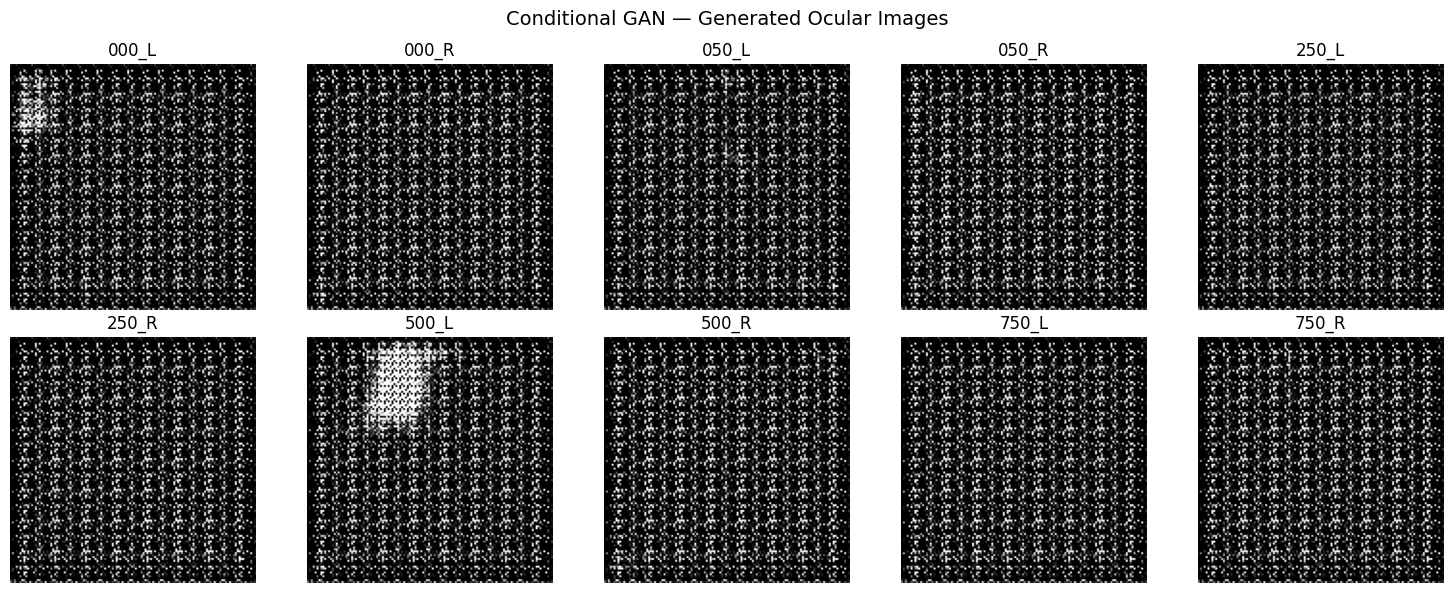

In [24]:
# Cell 23 — Generate Sample GAN Images

generator.eval()

# Select 10 different eye identities
sample_labels = torch.tensor(
    [0, 1, 100, 101, 500, 501, 1000, 1001, 1500, 1501],
    dtype=torch.long,
    device=device
)

# Fixed noise makes the visualization reproducible
torch.manual_seed(42)

sample_noise = torch.randn(
    len(sample_labels),
    LATENT_DIM,
    device=device
)

with torch.no_grad():
    generated_samples = generator(
        sample_noise,
        sample_labels
    )

# Convert [-1, 1] → [0, 1]
generated_samples = (
    generated_samples.clamp(-1, 1) + 1
) / 2

fig, axes = plt.subplots(
    2, 5,
    figsize=(15, 6)
)

for i, ax in enumerate(axes.flat):

    image = generated_samples[i].cpu().squeeze(0)

    ax.imshow(image, cmap="gray")
    ax.set_title(
        gan_label_to_identity[
            sample_labels[i].item()
        ]
    )
    ax.axis("off")

plt.suptitle(
    "Conditional GAN — Generated Ocular Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

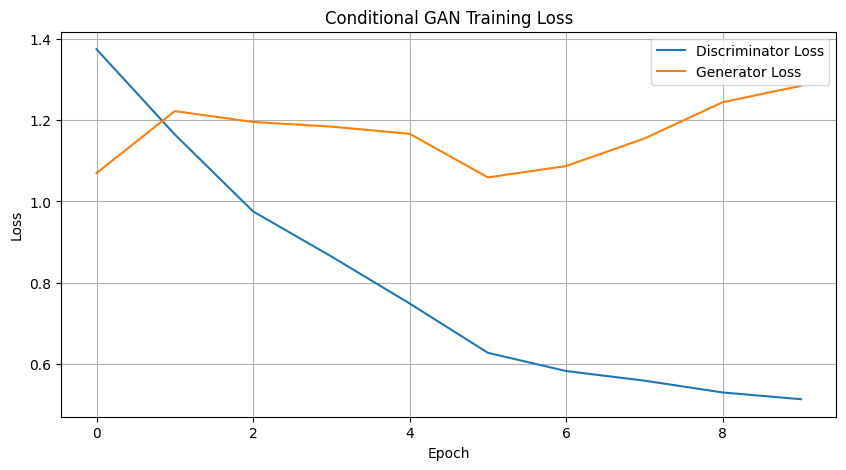

In [25]:
# Cell 24 — Plot GAN Training Curves

plt.figure(figsize=(10, 5))

plt.plot(D_losses, label="Discriminator Loss")
plt.plot(G_losses, label="Generator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Conditional GAN Training Loss")
plt.legend()
plt.grid(True)

plt.show()

In [26]:
# Cell 25 — Save First GAN Training History

gan_history = {
    "epochs": GAN_EPOCHS,
    "generator_loss": G_losses,
    "discriminator_loss": D_losses,
    "image_size": IMAGE_SIZE,
    "latent_dim": LATENT_DIM,
    "num_classes": NUM_CLASSES,
    "embedding_dim": EMBEDDING_DIM
}

gan_history_path = (
    project_path
    / "results"
    / "CASIA_Thousand_gan_initial_training_history.json"
)

with open(gan_history_path, "w") as f:
    json.dump(gan_history, f, indent=4)

print("GAN training history saved successfully.")
print("Path:", gan_history_path)

GAN training history saved successfully.
Path: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_gan_initial_training_history.json


In [27]:
# Cell 26 — Improved Conditional GAN Generator

class ImprovedGenerator(nn.Module):
    def __init__(
        self,
        latent_dim=LATENT_DIM,
        num_classes=NUM_CLASSES,
        embedding_dim=EMBEDDING_DIM
    ):
        super().__init__()

        # Learnable identity embedding
        self.identity_embedding = nn.Embedding(
            num_classes,
            embedding_dim
        )

        input_dim = latent_dim + embedding_dim

        # Project noise + identity into 8x8 feature map
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512 * 8 * 8),
            nn.BatchNorm1d(512 * 8 * 8),
            nn.ReLU(True)
        )

        # Upsampling + convolution
        # instead of ConvTranspose2d
        self.generator = nn.Sequential(

            # 8 → 16
            nn.Upsample(
                scale_factor=2,
                mode="nearest"
            ),
            nn.Conv2d(
                512, 256,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 16 → 32
            nn.Upsample(
                scale_factor=2,
                mode="nearest"
            ),
            nn.Conv2d(
                256, 128,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 32 → 64
            nn.Upsample(
                scale_factor=2,
                mode="nearest"
            ),
            nn.Conv2d(
                128, 64,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 → 128
            nn.Upsample(
                scale_factor=2,
                mode="nearest"
            ),
            nn.Conv2d(
                64, CHANNELS,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            # Output range [-1, 1]
            nn.Tanh()
        )

    def forward(self, noise, labels):

        # Identity information
        identity = self.identity_embedding(labels)

        # Combine noise and identity
        x = torch.cat(
            [noise, identity],
            dim=1
        )

        # Project to 8×8
        x = self.fc(x)

        x = x.view(
            x.size(0),
            512,
            8,
            8
        )

        # Generate image
        image = self.generator(x)

        return image


print("Improved Generator class created successfully.")

Improved Generator class created successfully.


In [28]:
# Cell 27 — Test Improved Generator

improved_generator = ImprovedGenerator().to(device)

test_noise = torch.randn(
    4,
    LATENT_DIM,
    device=device
)

test_labels = torch.tensor(
    [0, 1, 2, 3],
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    improved_output = improved_generator(
        test_noise,
        test_labels
    )

print("Improved Generator test successful.")
print("Input noise shape:", test_noise.shape)
print("Input label shape:", test_labels.shape)
print("Generated image shape:", improved_output.shape)
print(
    "Generated image range:",
    improved_output.min().item(),
    "to",
    improved_output.max().item()
)

Improved Generator test successful.
Input noise shape: torch.Size([4, 100])
Input label shape: torch.Size([4])
Generated image shape: torch.Size([4, 1, 128, 128])
Generated image range: -0.7461748123168945 to 0.9098302125930786


In [29]:
# Cell 28 — Initialize Improved GAN

# Use the improved Generator from scratch
generator = ImprovedGenerator().to(device)

# Fresh Discriminator
discriminator = Discriminator().to(device)

# Fresh optimizers
G_optimizer = optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

D_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

# Fresh loss tracking
G_losses_improved = []
D_losses_improved = []

print("Improved GAN initialized successfully.")
print("Generator parameters:",
      sum(p.numel() for p in generator.parameters()))
print("Discriminator parameters:",
      sum(p.numel() for p in discriminator.parameters()))
print("Device:", device)

Improved GAN initialized successfully.
Generator parameters: 7150017
Discriminator parameters: 4980673
Device: cuda


In [30]:
# Cell 29 — Train Improved GAN

GAN_EPOCHS_IMPROVED = 10

print("Starting improved GAN training...")
print("Epochs:", GAN_EPOCHS_IMPROVED)
print("Batches per epoch:", len(gan_loader))
print()

for epoch in range(GAN_EPOCHS_IMPROVED):

    generator.train()
    discriminator.train()

    running_G_loss = 0.0
    running_D_loss = 0.0

    start_time = time.time()

    for real_images, real_labels in gan_loader:

        real_images = real_images.to(
            device,
            non_blocking=True
        )
        real_labels = real_labels.to(
            device,
            non_blocking=True
        )

        batch_size = real_images.size(0)

        # ==================================================
        # 1. Train Discriminator
        # ==================================================

        D_optimizer.zero_grad()

        # Real images → target 1
        real_targets = torch.ones(
            batch_size, 1,
            device=device
        )

        real_scores = discriminator(
            real_images,
            real_labels
        )

        D_real_loss = criterion_gan(
            real_scores,
            real_targets
        )

        # Generate fake images
        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = generator(
            noise,
            real_labels
        )

        # Fake images → target 0
        fake_targets = torch.zeros(
            batch_size, 1,
            device=device
        )

        fake_scores = discriminator(
            fake_images.detach(),
            real_labels
        )

        D_fake_loss = criterion_gan(
            fake_scores,
            fake_targets
        )

        D_loss = D_real_loss + D_fake_loss

        D_loss.backward()
        D_optimizer.step()

        # ==================================================
        # 2. Train Generator
        # ==================================================

        G_optimizer.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = generator(
            noise,
            real_labels
        )

        fake_scores = discriminator(
            fake_images,
            real_labels
        )

        # Generator wants fake images classified as real
        G_loss = criterion_gan(
            fake_scores,
            real_targets
        )

        G_loss.backward()
        G_optimizer.step()

        # ==================================================
        # 3. Record losses
        # ==================================================

        running_D_loss += D_loss.item()
        running_G_loss += G_loss.item()

    avg_D_loss = running_D_loss / len(gan_loader)
    avg_G_loss = running_G_loss / len(gan_loader)

    D_losses_improved.append(avg_D_loss)
    G_losses_improved.append(avg_G_loss)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{GAN_EPOCHS_IMPROVED}] | "
        f"D Loss: {avg_D_loss:.4f} | "
        f"G Loss: {avg_G_loss:.4f} | "
        f"Time: {elapsed/60:.2f} min"
    )

print()
print("Improved GAN training completed.")

Starting improved GAN training...
Epochs: 10
Batches per epoch: 188

Epoch [1/10] | D Loss: 1.4147 | G Loss: 0.7981 | Time: 1.06 min
Epoch [2/10] | D Loss: 1.3164 | G Loss: 0.8267 | Time: 1.06 min
Epoch [3/10] | D Loss: 1.2084 | G Loss: 0.8860 | Time: 1.05 min
Epoch [4/10] | D Loss: 1.1174 | G Loss: 0.9664 | Time: 1.06 min
Epoch [5/10] | D Loss: 1.0226 | G Loss: 1.0356 | Time: 1.06 min
Epoch [6/10] | D Loss: 0.9427 | G Loss: 1.1426 | Time: 1.06 min
Epoch [7/10] | D Loss: 0.8839 | G Loss: 1.2035 | Time: 1.06 min
Epoch [8/10] | D Loss: 0.8300 | G Loss: 1.2978 | Time: 1.05 min
Epoch [9/10] | D Loss: 0.7941 | G Loss: 1.3869 | Time: 1.05 min
Epoch [10/10] | D Loss: 0.7608 | G Loss: 1.4536 | Time: 1.06 min

Improved GAN training completed.


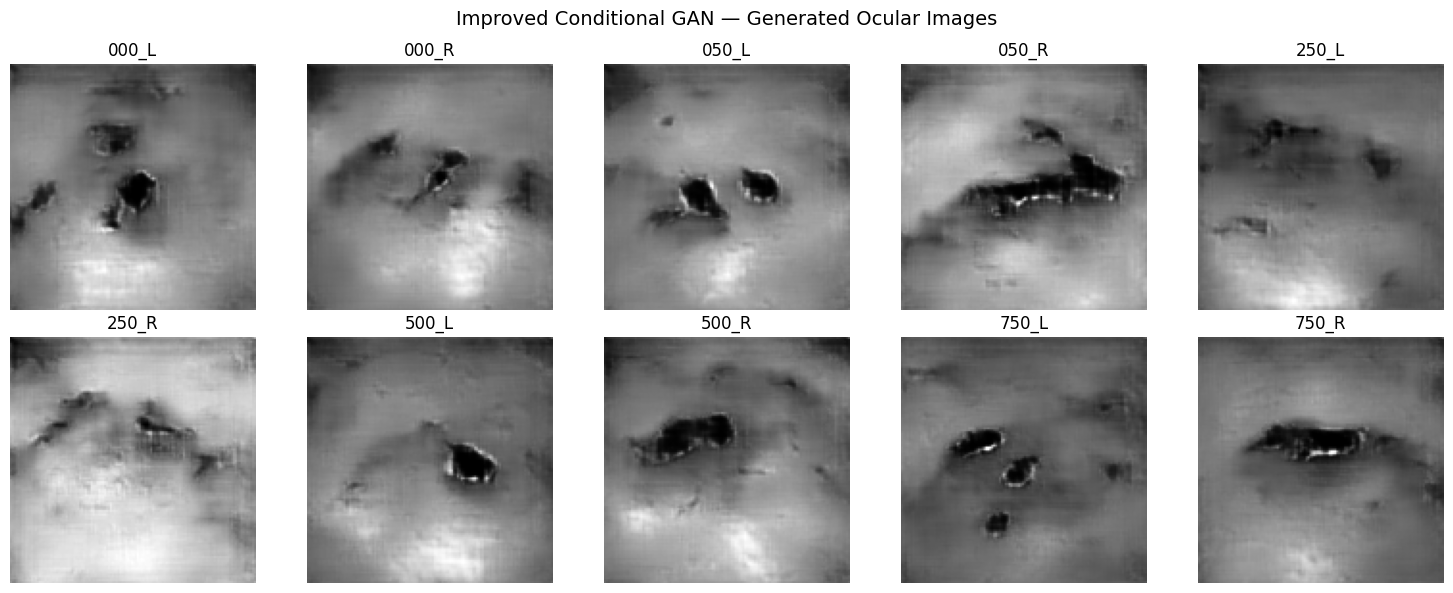

In [31]:
# Cell 30 — Visualize Improved GAN Samples

generator.eval()

# Use several identities
sample_labels = torch.tensor(
    [0, 1, 100, 101, 500, 501, 1000, 1001, 1500, 1501],
    dtype=torch.long,
    device=device
)

# Fixed noise for reproducibility
torch.manual_seed(42)

sample_noise = torch.randn(
    len(sample_labels),
    LATENT_DIM,
    device=device
)

with torch.no_grad():
    generated_samples = generator(
        sample_noise,
        sample_labels
    )

# Convert [-1, 1] → [0, 1]
generated_samples = (
    generated_samples.clamp(-1, 1) + 1
) / 2

fig, axes = plt.subplots(
    2, 5,
    figsize=(15, 6)
)

for i, ax in enumerate(axes.flat):

    image = generated_samples[i].cpu().squeeze(0)

    ax.imshow(image, cmap="gray")
    ax.set_title(
        gan_label_to_identity[
            sample_labels[i].item()
        ]
    )
    ax.axis("off")

plt.suptitle(
    "Improved Conditional GAN — Generated Ocular Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [32]:
# Cell 31 — Save Improved GAN Training History

improved_gan_history = {
    "epochs": GAN_EPOCHS_IMPROVED,
    "generator_loss": G_losses_improved,
    "discriminator_loss": D_losses_improved,
    "image_size": IMAGE_SIZE,
    "latent_dim": LATENT_DIM,
    "num_classes": NUM_CLASSES,
    "embedding_dim": EMBEDDING_DIM,
    "architecture": "Upsampling + Convolution Conditional GAN"
}

improved_gan_history_path = (
    project_path
    / "results"
    / "CASIA_Thousand_gan_improved_training_history.json"
)

with open(improved_gan_history_path, "w") as f:
    json.dump(
        improved_gan_history,
        f,
        indent=4
    )

print("Improved GAN training history saved successfully.")
print("Path:", improved_gan_history_path)

Improved GAN training history saved successfully.
Path: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_gan_improved_training_history.json


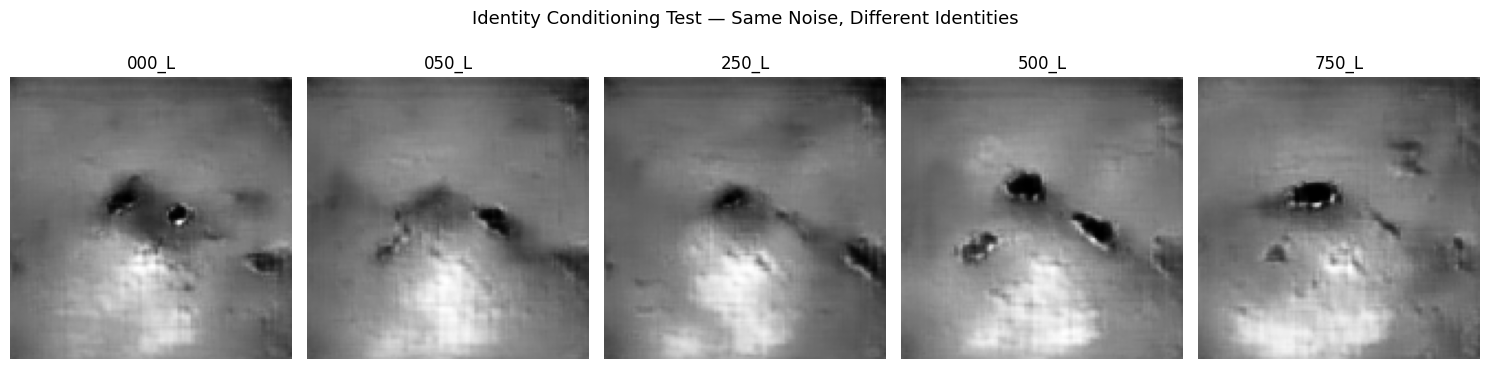

In [33]:
# Cell 32 — Identity Conditioning Test

generator.eval()

# Use the SAME noise vector for every identity
torch.manual_seed(123)

fixed_noise = torch.randn(
    1,
    LATENT_DIM,
    device=device
)

# Generate the same noise with different identities
identity_labels = torch.tensor(
    [0, 100, 500, 1000, 1500],
    dtype=torch.long,
    device=device
)

with torch.no_grad():
    identity_samples = generator(
        fixed_noise.repeat(len(identity_labels), 1),
        identity_labels
    )

# Convert [-1, 1] → [0, 1]
identity_samples = (
    identity_samples.clamp(-1, 1) + 1
) / 2

fig, axes = plt.subplots(
    1, 5,
    figsize=(15, 4)
)

for i, ax in enumerate(axes):

    image = identity_samples[i].cpu().squeeze(0)

    ax.imshow(image, cmap="gray")
    ax.set_title(
        gan_label_to_identity[
            identity_labels[i].item()
        ]
    )
    ax.axis("off")

plt.suptitle(
    "Identity Conditioning Test — Same Noise, Different Identities",
    fontsize=13
)

plt.tight_layout()
plt.show()

In [34]:
# Cell 33 — Load Baseline ResNet18 for Identity Evaluation

import torch.nn.functional as F
from torchvision import models

# Create the same ResNet18 architecture used in Notebook 04
identity_model = models.resnet18(weights=None)

# Grayscale input
identity_model.conv1 = nn.Conv2d(
    1,
    64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# 2,000 eye identities
identity_model.fc = nn.Linear(
    identity_model.fc.in_features,
    NUM_CLASSES
)

# Load trained baseline weights
baseline_model_path = (
    project_path
    / "models"
    / "CASIA_Thousand_baseline_resnet18.pth"
)

identity_model.load_state_dict(
    torch.load(
        baseline_model_path,
        map_location=device
    )
)

identity_model = identity_model.to(device)
identity_model.eval()

print("Baseline identity model loaded successfully.")
print("Model:", "ResNet18")
print("Number of classes:", NUM_CLASSES)
print("Device:", device)

Baseline identity model loaded successfully.
Model: ResNet18
Number of classes: 2000
Device: cuda


In [35]:
# Cell 34 — Evaluate GAN Identity Preservation

generator.eval()
identity_model.eval()

NUM_IDENTITY_TESTS = 100

# Select the first 100 identities
test_identity_labels = torch.arange(
    NUM_IDENTITY_TESTS,
    dtype=torch.long,
    device=device
)

# Use fixed random noise
torch.manual_seed(2026)

identity_test_noise = torch.randn(
    NUM_IDENTITY_TESTS,
    LATENT_DIM,
    device=device
)

# Generate synthetic images
with torch.no_grad():
    synthetic_images = generator(
        identity_test_noise,
        test_identity_labels
    )

    # Resize from 128 → 256 for ResNet18
    synthetic_images_256 = F.interpolate(
        synthetic_images,
        size=(256, 256),
        mode="bilinear",
        align_corners=False
    )

    # GAN output is [-1, 1]
    # Convert to [0, 1] for the ResNet
    synthetic_images_256 = (
        synthetic_images_256.clamp(-1, 1) + 1
    ) / 2

    # ResNet predictions
    predictions = identity_model(
        synthetic_images_256
    )

    predicted_labels = predictions.argmax(
        dim=1
    )

# Calculate identity matching accuracy
identity_accuracy = (
    predicted_labels == test_identity_labels
).float().mean().item() * 100

print("GAN Identity Evaluation")
print("-----------------------")
print("Identities tested:", NUM_IDENTITY_TESTS)
print(
    f"Identity recognition accuracy: "
    f"{identity_accuracy:.2f}%"
)

GAN Identity Evaluation
-----------------------
Identities tested: 100
Identity recognition accuracy: 1.00%


In [36]:
# Cell 35 — Real vs GAN Image Statistics

generator.eval()

# Generate 100 synthetic images
torch.manual_seed(2027)

comparison_labels = torch.randint(
    0,
    NUM_CLASSES,
    (100,),
    device=device
)

comparison_noise = torch.randn(
    100,
    LATENT_DIM,
    device=device
)

with torch.no_grad():
    synthetic = generator(
        comparison_noise,
        comparison_labels
    )

# Convert GAN output [-1, 1] → [0, 1]
synthetic = (
    synthetic.clamp(-1, 1) + 1
) / 2

# Get 100 real images
real_batch, _ = next(iter(gan_loader))

real_batch = (
    real_batch[:100].cpu() + 1
) / 2

# Calculate statistics
real_mean = real_batch.mean().item()
real_std = real_batch.std().item()

synthetic_mean = synthetic.cpu().mean().item()
synthetic_std = synthetic.cpu().std().item()

print("Real vs GAN Image Statistics")
print("----------------------------")
print(f"Real images      - Mean: {real_mean:.4f}, Std: {real_std:.4f}")
print(f"GAN images       - Mean: {synthetic_mean:.4f}, Std: {synthetic_std:.4f}")

Real vs GAN Image Statistics
----------------------------
Real images      - Mean: 0.3816, Std: 0.1180
GAN images       - Mean: 0.3909, Std: 0.1369


In [37]:
# Cell 36 — Save GAN Evaluation Results

gan_evaluation = {
    "initial_gan": {
        "visual_quality": "Mostly noise and checkerboard artifacts",
        "identity_evaluation_accuracy_percent": None
    },
    "improved_gan": {
        "visual_quality": "Coarse ocular structure but blurry and distorted",
        "identity_evaluation_accuracy_percent": identity_accuracy,
        "real_mean": real_mean,
        "real_std": real_std,
        "gan_mean": synthetic_mean,
        "gan_std": synthetic_std
    }
}

gan_evaluation_path = (
    project_path
    / "results"
    / "CASIA_Thousand_gan_evaluation_results.json"
)

with open(gan_evaluation_path, "w") as f:
    json.dump(
        gan_evaluation,
        f,
        indent=4
    )

print("GAN evaluation results saved successfully.")
print("Path:", gan_evaluation_path)

GAN evaluation results saved successfully.
Path: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_gan_evaluation_results.json


In [38]:
# Cell 37 — Save Trained Improved GAN

gan_model_path = (
    project_path
    / "models"
    / "CASIA_Thousand_improved_conditional_gan.pth"
)

torch.save(
    {
        "generator_state_dict": generator.state_dict(),
        "discriminator_state_dict": discriminator.state_dict(),
        "latent_dim": LATENT_DIM,
        "num_classes": NUM_CLASSES,
        "embedding_dim": EMBEDDING_DIM,
        "image_size": IMAGE_SIZE
    },
    gan_model_path
)

print("Trained GAN model saved successfully.")
print("Path:", gan_model_path)

Trained GAN model saved successfully.
Path: /content/drive/MyDrive/Ocular_Project/models/CASIA_Thousand_improved_conditional_gan.pth


In [39]:
# Cell 38 — Prepare Unconditional GAN DataLoader

unconditional_gan_loader = DataLoader(
    gan_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Unconditional GAN DataLoader ready.")
print("Training images:", len(gan_dataset))
print("Batch size:", 64)
print("Batches per epoch:", len(unconditional_gan_loader))

Unconditional GAN DataLoader ready.
Training images: 12000
Batch size: 64
Batches per epoch: 188


In [40]:
# Cell 39 — Third GAN Generator

class OcularGenerator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 512 * 8 * 8),
            nn.BatchNorm1d(512 * 8 * 8),
            nn.ReLU(True)
        )

        self.net = nn.Sequential(

            # 8 × 8 → 16 × 16
            nn.Upsample(
                scale_factor=2,
                mode="nearest"
            ),
            nn.Conv2d(
                512, 256,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 16 × 16 → 32 × 32
            nn.Upsample(
                scale_factor=2,
                mode="nearest"
            ),
            nn.Conv2d(
                256, 128,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 32 × 32 → 64 × 64
            nn.Upsample(
                scale_factor=2,
                mode="nearest"
            ),
            nn.Conv2d(
                128, 64,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 × 64 → 128 × 128
            nn.Upsample(
                scale_factor=2,
                mode="nearest"
            ),
            nn.Conv2d(
                64, 32,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # Final image
            nn.Conv2d(
                32, 1,
                kernel_size=3,
                padding=1
            ),

            nn.Tanh()
        )

    def forward(self, noise):

        x = self.fc(noise)

        x = x.view(
            x.size(0),
            512,
            8,
            8
        )

        return self.net(x)


print("Third GAN Generator class created successfully.")

Third GAN Generator class created successfully.


In [41]:
# Cell 40 — Third GAN Discriminator

class OcularDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(

            # 128 × 128 → 64 × 64
            nn.utils.spectral_norm(
                nn.Conv2d(
                    1, 64,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 × 64 → 32 × 32
            nn.utils.spectral_norm(
                nn.Conv2d(
                    64, 128,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 × 32 → 16 × 16
            nn.utils.spectral_norm(
                nn.Conv2d(
                    128, 256,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 × 16 → 8 × 8
            nn.utils.spectral_norm(
                nn.Conv2d(
                    256, 512,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 × 8 → 4 × 4
            nn.utils.spectral_norm(
                nn.Conv2d(
                    512, 512,
                    kernel_size=4,
                    stride=2,
                    padding=1
                )
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),

            # Final real/fake logit
            nn.utils.spectral_norm(
                nn.Linear(
                    512 * 4 * 4,
                    1
                )
            )
        )

    def forward(self, image):
        return self.net(image)


print("Third GAN Discriminator class created successfully.")

Third GAN Discriminator class created successfully.


In [42]:
# Cell 41 — Test Third GAN

ocular_generator = OcularGenerator().to(device)
ocular_discriminator = OcularDiscriminator().to(device)

# Test noise
test_noise = torch.randn(
    4,
    LATENT_DIM,
    device=device
)

with torch.no_grad():
    test_fake_images = ocular_generator(test_noise)
    test_fake_scores = ocular_discriminator(test_fake_images)

print("Third GAN test successful.")
print()
print("Noise shape:", test_noise.shape)
print("Generated image shape:", test_fake_images.shape)
print("Discriminator output shape:", test_fake_scores.shape)
print(
    "Generated image range:",
    test_fake_images.min().item(),
    "to",
    test_fake_images.max().item()
)

print()
print(
    "Generator parameters:",
    sum(p.numel() for p in ocular_generator.parameters())
)

print(
    "Discriminator parameters:",
    sum(p.numel() for p in ocular_discriminator.parameters())
)

Third GAN test successful.

Noise shape: torch.Size([4, 100])
Generated image shape: torch.Size([4, 1, 128, 128])
Discriminator output shape: torch.Size([4, 1])
Generated image range: -0.8089926242828369 to 0.9220892190933228

Generator parameters: 4943073
Discriminator parameters: 6957505


In [43]:
# Cell 42 — Third GAN Training Setup

THIRD_GAN_EPOCHS = 15

# Move models to GPU
ocular_generator = ocular_generator.to(device)
ocular_discriminator = ocular_discriminator.to(device)

# GAN loss
third_gan_criterion = nn.BCEWithLogitsLoss()

# Optimizers
third_G_optimizer = optim.Adam(
    ocular_generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

third_D_optimizer = optim.Adam(
    ocular_discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

# Loss history
third_G_losses = []
third_D_losses = []

# One-sided label smoothing
REAL_LABEL = 0.9
FAKE_LABEL = 0.0

print("Third GAN training setup complete.")
print("Epochs:", THIRD_GAN_EPOCHS)
print("Real label:", REAL_LABEL)
print("Fake label:", FAKE_LABEL)
print("Device:", device)

Third GAN training setup complete.
Epochs: 15
Real label: 0.9
Fake label: 0.0
Device: cuda


In [44]:
# Cell 43 — Train Third GAN

# Fixed noise for monitoring generator progress
torch.manual_seed(2026)

fixed_noise = torch.randn(
    16,
    LATENT_DIM,
    device=device
)

for epoch in range(THIRD_GAN_EPOCHS):

    ocular_generator.train()
    ocular_discriminator.train()

    running_G_loss = 0.0
    running_D_loss = 0.0

    start_time = time.time()

    for real_images, _ in unconditional_gan_loader:

        real_images = real_images.to(
            device,
            non_blocking=True
        )

        batch_size = real_images.size(0)

        # ==============================================
        # 1. Train Discriminator
        # ==============================================

        third_D_optimizer.zero_grad()

        # Real images
        real_targets = torch.full(
            (batch_size, 1),
            REAL_LABEL,
            device=device
        )

        real_scores = ocular_discriminator(
            real_images
        )

        D_real_loss = third_gan_criterion(
            real_scores,
            real_targets
        )

        # Fake images
        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = ocular_generator(noise)

        fake_targets = torch.full(
            (batch_size, 1),
            FAKE_LABEL,
            device=device
        )

        fake_scores = ocular_discriminator(
            fake_images.detach()
        )

        D_fake_loss = third_gan_criterion(
            fake_scores,
            fake_targets
        )

        # Total discriminator loss
        D_loss = D_real_loss + D_fake_loss

        D_loss.backward()
        third_D_optimizer.step()

        # ==============================================
        # 2. Train Generator
        # ==============================================

        third_G_optimizer.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = ocular_generator(noise)

        fake_scores = ocular_discriminator(
            fake_images
        )

        # Generator wants fake → real
        G_targets = torch.full(
            (batch_size, 1),
            REAL_LABEL,
            device=device
        )

        G_loss = third_gan_criterion(
            fake_scores,
            G_targets
        )

        G_loss.backward()
        third_G_optimizer.step()

        running_D_loss += D_loss.item()
        running_G_loss += G_loss.item()

    avg_D_loss = (
        running_D_loss /
        len(unconditional_gan_loader)
    )

    avg_G_loss = (
        running_G_loss /
        len(unconditional_gan_loader)
    )

    third_D_losses.append(avg_D_loss)
    third_G_losses.append(avg_G_loss)

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch + 1}/{THIRD_GAN_EPOCHS}] | "
        f"D Loss: {avg_D_loss:.4f} | "
        f"G Loss: {avg_G_loss:.4f} | "
        f"Time: {elapsed / 60:.2f} min"
    )

print()
print("Third GAN training completed.")

Epoch [1/15] | D Loss: 1.3174 | G Loss: 0.9617 | Time: 1.54 min
Epoch [2/15] | D Loss: 1.3090 | G Loss: 0.8907 | Time: 1.54 min
Epoch [3/15] | D Loss: 1.2888 | G Loss: 0.9174 | Time: 1.52 min
Epoch [4/15] | D Loss: 1.2686 | G Loss: 0.9160 | Time: 1.53 min
Epoch [5/15] | D Loss: 1.2615 | G Loss: 0.9248 | Time: 1.52 min
Epoch [6/15] | D Loss: 1.2573 | G Loss: 0.9309 | Time: 1.54 min
Epoch [7/15] | D Loss: 1.2490 | G Loss: 0.9436 | Time: 1.54 min
Epoch [8/15] | D Loss: 1.2437 | G Loss: 0.9533 | Time: 1.54 min
Epoch [9/15] | D Loss: 1.2457 | G Loss: 0.9630 | Time: 1.53 min
Epoch [10/15] | D Loss: 1.2433 | G Loss: 0.9573 | Time: 1.53 min
Epoch [11/15] | D Loss: 1.2536 | G Loss: 0.9471 | Time: 1.53 min
Epoch [12/15] | D Loss: 1.2578 | G Loss: 0.9488 | Time: 1.53 min
Epoch [13/15] | D Loss: 1.2687 | G Loss: 0.9397 | Time: 1.53 min
Epoch [14/15] | D Loss: 1.2675 | G Loss: 0.9210 | Time: 1.54 min
Epoch [15/15] | D Loss: 1.2736 | G Loss: 0.9178 | Time: 1.53 min

Third GAN training completed.


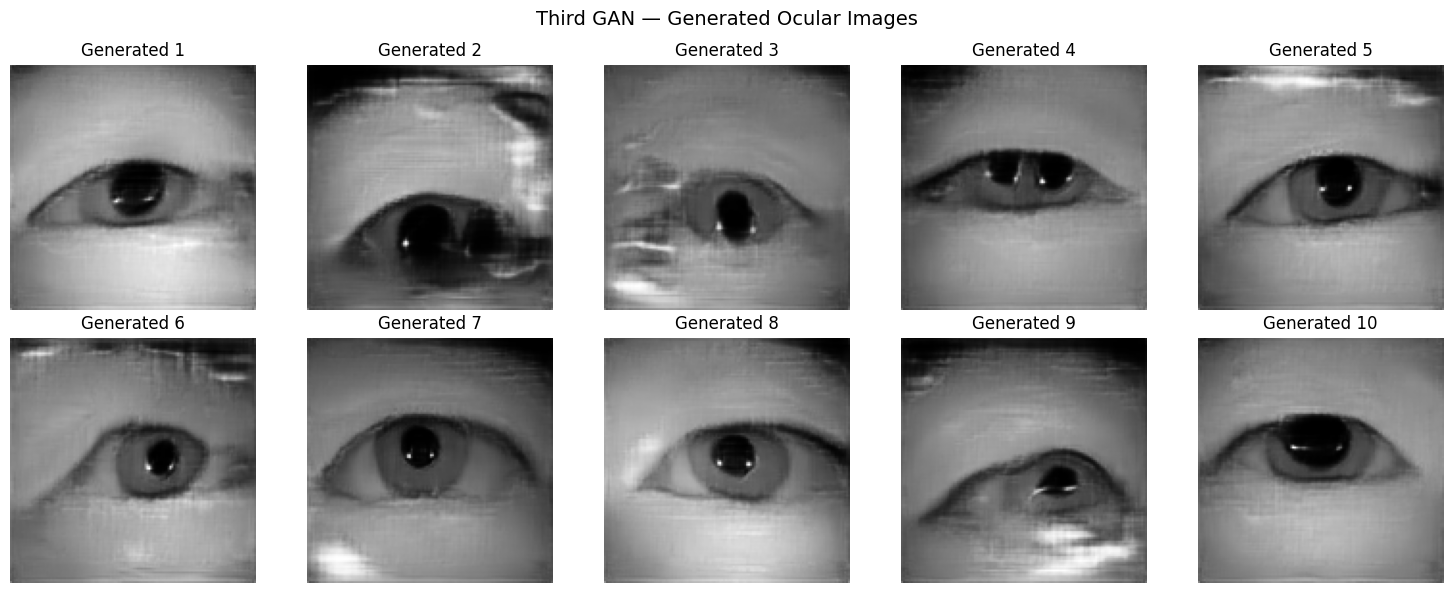

In [45]:
# Cell 44 — Visualize Third GAN Samples

ocular_generator.eval()

torch.manual_seed(42)

sample_noise = torch.randn(
    10,
    LATENT_DIM,
    device=device
)

with torch.no_grad():
    generated_samples = ocular_generator(
        sample_noise
    )

# Convert [-1, 1] → [0, 1]
generated_samples = (
    generated_samples.clamp(-1, 1) + 1
) / 2

fig, axes = plt.subplots(
    2, 5,
    figsize=(15, 6)
)

for i, ax in enumerate(axes.flat):

    image = generated_samples[i].cpu().squeeze(0)

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Generated {i + 1}")
    ax.axis("off")

plt.suptitle(
    "Third GAN — Generated Ocular Images",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [46]:
# Cell 45 — Continue Third GAN Training

ADDITIONAL_EPOCHS = 15

print("Continuing third GAN training...")
print("Additional epochs:", ADDITIONAL_EPOCHS)
print()

for epoch in range(ADDITIONAL_EPOCHS):

    ocular_generator.train()
    ocular_discriminator.train()

    running_G_loss = 0.0
    running_D_loss = 0.0

    start_time = time.time()

    for real_images, _ in unconditional_gan_loader:

        real_images = real_images.to(
            device,
            non_blocking=True
        )

        batch_size = real_images.size(0)

        # ==============================================
        # Train Discriminator
        # ==============================================

        third_D_optimizer.zero_grad()

        real_targets = torch.full(
            (batch_size, 1),
            REAL_LABEL,
            device=device
        )

        real_scores = ocular_discriminator(
            real_images
        )

        D_real_loss = third_gan_criterion(
            real_scores,
            real_targets
        )

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = ocular_generator(noise)

        fake_targets = torch.zeros(
            batch_size, 1,
            device=device
        )

        fake_scores = ocular_discriminator(
            fake_images.detach()
        )

        D_fake_loss = third_gan_criterion(
            fake_scores,
            fake_targets
        )

        D_loss = D_real_loss + D_fake_loss

        D_loss.backward()
        third_D_optimizer.step()

        # ==============================================
        # Train Generator
        # ==============================================

        third_G_optimizer.zero_grad()

        noise = torch.randn(
            batch_size,
            LATENT_DIM,
            device=device
        )

        fake_images = ocular_generator(noise)

        fake_scores = ocular_discriminator(
            fake_images
        )

        G_targets = torch.full(
            (batch_size, 1),
            REAL_LABEL,
            device=device
        )

        G_loss = third_gan_criterion(
            fake_scores,
            G_targets
        )

        G_loss.backward()
        third_G_optimizer.step()

        running_D_loss += D_loss.item()
        running_G_loss += G_loss.item()

    avg_D_loss = (
        running_D_loss /
        len(unconditional_gan_loader)
    )

    avg_G_loss = (
        running_G_loss /
        len(unconditional_gan_loader)
    )

    third_D_losses.append(avg_D_loss)
    third_G_losses.append(avg_G_loss)

    elapsed = time.time() - start_time

    print(
        f"Additional Epoch [{epoch + 1}/{ADDITIONAL_EPOCHS}] | "
        f"D Loss: {avg_D_loss:.4f} | "
        f"G Loss: {avg_G_loss:.4f} | "
        f"Time: {elapsed / 60:.2f} min"
    )

print()
print("Third GAN additional training completed.")
print("Total training epochs:", len(third_G_losses))

Continuing third GAN training...
Additional epochs: 15

Additional Epoch [1/15] | D Loss: 1.2741 | G Loss: 0.9193 | Time: 1.53 min
Additional Epoch [2/15] | D Loss: 1.2731 | G Loss: 0.9148 | Time: 1.53 min
Additional Epoch [3/15] | D Loss: 1.2839 | G Loss: 0.9159 | Time: 1.52 min
Additional Epoch [4/15] | D Loss: 1.2775 | G Loss: 0.9103 | Time: 1.52 min
Additional Epoch [5/15] | D Loss: 1.2821 | G Loss: 0.9089 | Time: 1.53 min
Additional Epoch [6/15] | D Loss: 1.2794 | G Loss: 0.9098 | Time: 1.53 min
Additional Epoch [7/15] | D Loss: 1.2839 | G Loss: 0.9065 | Time: 1.53 min
Additional Epoch [8/15] | D Loss: 1.2783 | G Loss: 0.9095 | Time: 1.53 min
Additional Epoch [9/15] | D Loss: 1.2814 | G Loss: 0.9061 | Time: 1.53 min
Additional Epoch [10/15] | D Loss: 1.2810 | G Loss: 0.9047 | Time: 1.53 min
Additional Epoch [11/15] | D Loss: 1.2788 | G Loss: 0.9123 | Time: 1.53 min
Additional Epoch [12/15] | D Loss: 1.2766 | G Loss: 0.9084 | Time: 1.53 min
Additional Epoch [13/15] | D Loss: 1.2773

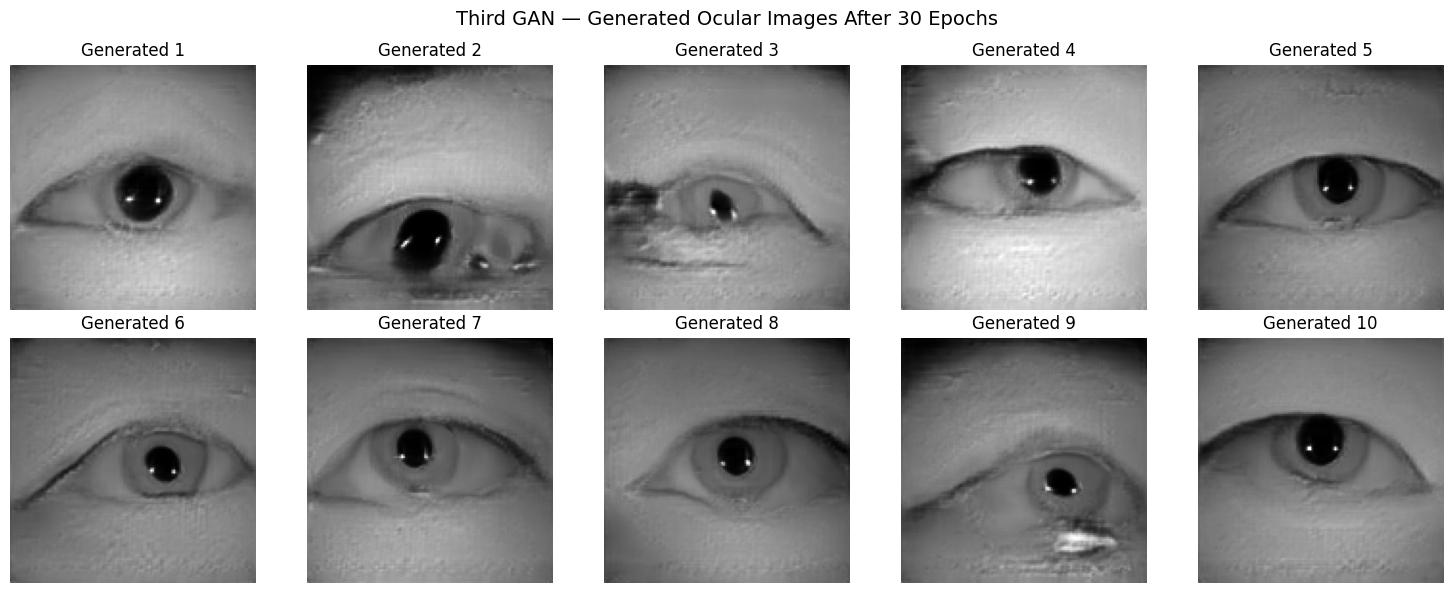

In [47]:
# Cell 46 — Visualize Third GAN After 30 Epochs

ocular_generator.eval()

torch.manual_seed(42)

sample_noise = torch.randn(
    10,
    LATENT_DIM,
    device=device
)

with torch.no_grad():
    generated_samples_30 = ocular_generator(sample_noise)

generated_samples_30 = (
    generated_samples_30.clamp(-1, 1) + 1
) / 2

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):

    image = generated_samples_30[i].cpu().squeeze()

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Generated {i+1}")
    ax.axis("off")

plt.suptitle(
    "Third GAN — Generated Ocular Images After 30 Epochs",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [48]:
# Cell 48 — Save Final Third GAN Model

final_gan_model_path = (
    project_path
    / "models"
    / "CASIA_Thousand_third_gan_30epochs.pth"
)

torch.save(
    {
        "generator_state_dict": ocular_generator.state_dict(),
        "discriminator_state_dict": ocular_discriminator.state_dict(),
        "latent_dim": LATENT_DIM,
        "image_size": IMAGE_SIZE,
        "channels": CHANNELS,
        "epochs": 30,
        "architecture": "Unconditional GAN with Spectral Normalization"
    },
    final_gan_model_path
)

print("Final third GAN model saved successfully.")
print("Path:", final_gan_model_path)

Final third GAN model saved successfully.
Path: /content/drive/MyDrive/Ocular_Project/models/CASIA_Thousand_third_gan_30epochs.pth


In [49]:
# Cell 49 — Save Third GAN Training History

third_gan_history = {
    "total_epochs": len(third_G_losses),
    "generator_loss": third_G_losses,
    "discriminator_loss": third_D_losses,
    "latent_dimension": LATENT_DIM,
    "image_size": IMAGE_SIZE,
    "channels": CHANNELS,
    "batch_size": 64,
    "learning_rate": 0.0002,
    "real_label": REAL_LABEL,
    "fake_label": FAKE_LABEL,
    "architecture": "Unconditional GAN with Upsampling Generator and Spectral Normalization Discriminator"
}

third_gan_history_path = (
    project_path
    / "results"
    / "CASIA_Thousand_third_gan_30epochs_history.json"
)

with open(third_gan_history_path, "w") as f:
    json.dump(
        third_gan_history,
        f,
        indent=4
    )

print("Third GAN 30-epoch history saved successfully.")
print("Path:", third_gan_history_path)
print("Total epochs recorded:", len(third_G_losses))

Third GAN 30-epoch history saved successfully.
Path: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_third_gan_30epochs_history.json
Total epochs recorded: 30


In [50]:
# Cell 50 — Third GAN Diversity Test

ocular_generator.eval()

torch.manual_seed(2026)

diversity_noise = torch.randn(
    100,
    LATENT_DIM,
    device=device
)

with torch.no_grad():
    diversity_images = ocular_generator(
        diversity_noise
    )

# Convert [-1, 1] → [0, 1]
diversity_images = (
    diversity_images.clamp(-1, 1) + 1
) / 2

# Flatten each image
flat_images = diversity_images.view(
    100,
    -1
)

# Normalize each image vector
flat_images = torch.nn.functional.normalize(
    flat_images,
    p=2,
    dim=1
)

# Cosine similarity matrix
similarity_matrix = torch.mm(
    flat_images,
    flat_images.t()
)

# Take upper triangular values,
# excluding the diagonal
upper_indices = torch.triu_indices(
    100,
    100,
    offset=1
)

pairwise_similarity = similarity_matrix[
    upper_indices[0],
    upper_indices[1]
]

mean_similarity = pairwise_similarity.mean().item()

# Convert similarity to a simple diversity measure
mean_diversity = 1 - mean_similarity

print("Third GAN Diversity Test")
print("------------------------")
print("Images generated:", 100)
print(f"Mean pairwise cosine similarity: {mean_similarity:.4f}")
print(f"Mean diversity score: {mean_diversity:.4f}")

Third GAN Diversity Test
------------------------
Images generated: 100
Mean pairwise cosine similarity: 0.9575
Mean diversity score: 0.0425


In [51]:
# Cell 51 — Compare Real and GAN Diversity

def calculate_mean_similarity(images):
    """
    Calculate mean pairwise cosine similarity.
    images shape: [N, 1, H, W]
    """

    flat = images.view(
        images.size(0),
        -1
    )

    flat = torch.nn.functional.normalize(
        flat,
        p=2,
        dim=1
    )

    similarity = torch.mm(
        flat,
        flat.t()
    )

    indices = torch.triu_indices(
        images.size(0),
        images.size(0),
        offset=1
    )

    pairwise = similarity[
        indices[0],
        indices[1]
    ]

    return pairwise.mean().item()


# ---------------------------------------------
# Real images
# ---------------------------------------------

real_diversity_batch, _ = next(
    iter(unconditional_gan_loader)
)

real_diversity_batch = (
    real_diversity_batch[:100].cpu() + 1
) / 2


# ---------------------------------------------
# GAN images
# ---------------------------------------------

ocular_generator.eval()

torch.manual_seed(2026)

comparison_noise = torch.randn(
    100,
    LATENT_DIM,
    device=device
)

with torch.no_grad():

    generated_diversity_batch = (
        ocular_generator(
            comparison_noise
        ).cpu()
    )

generated_diversity_batch = (
    generated_diversity_batch.clamp(-1, 1) + 1
) / 2


# ---------------------------------------------
# Calculate similarities
# ---------------------------------------------

real_similarity = calculate_mean_similarity(
    real_diversity_batch
)

gan_similarity = calculate_mean_similarity(
    generated_diversity_batch
)

real_diversity_score = 1 - real_similarity
gan_diversity_score = 1 - gan_similarity


print("Real vs GAN Diversity")
print("---------------------")

print(
    f"Real mean pairwise similarity: "
    f"{real_similarity:.4f}"
)

print(
    f"Real diversity score: "
    f"{real_diversity_score:.4f}"
)

print()

print(
    f"GAN mean pairwise similarity: "
    f"{gan_similarity:.4f}"
)

print(
    f"GAN diversity score: "
    f"{gan_diversity_score:.4f}"
)

Real vs GAN Diversity
---------------------
Real mean pairwise similarity: 0.9482
Real diversity score: 0.0518

GAN mean pairwise similarity: 0.9575
GAN diversity score: 0.0425


In [52]:
# Cell 52 — Save GAN Diversity Results

gan_diversity_results = {
    "num_images": 100,
    "metric": "Pixel-space mean pairwise cosine similarity",
    "real_mean_similarity": real_similarity,
    "real_diversity_score": real_diversity_score,
    "gan_mean_similarity": gan_similarity,
    "gan_diversity_score": gan_diversity_score,
    "interpretation": (
        "GAN samples showed lower pixel-space diversity "
        "than the sampled real training images."
    )
}

gan_diversity_path = (
    project_path
    / "results"
    / "CASIA_Thousand_gan_diversity_results.json"
)

with open(gan_diversity_path, "w") as f:
    json.dump(
        gan_diversity_results,
        f,
        indent=4
    )

print("GAN diversity results saved successfully.")
print("Path:", gan_diversity_path)

GAN diversity results saved successfully.
Path: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_gan_diversity_results.json
